# Simulación de Goles de Partido de Fútbol

Usando distribución de Poisson basada en ratings Elo de equipos

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
import random

## Cargar ratings de equipos

In [2]:
# Cargar los ratings
ratings_df = pd.read_csv('output/ratings_championship.csv')
print("Ratings cargados:")
print(ratings_df.head(10))

Ratings cargados:
        Equipo       Rating
0        Spain  1807.709340
1       France  1775.751136
2    Argentina  1753.136721
3      England  1749.580139
4  Netherlands  1707.512013
5        Japan  1704.299788
6     Portugal  1692.415652
7      Germany  1679.939508
8      Morocco  1678.319761
9      Croatia  1670.307297


## Función para calcular lambda (goles esperados)

In [31]:
def get_team_rating(team_name, ratings_df):
    """Obtener el rating de un equipo"""
    rating = ratings_df[ratings_df['Equipo'] == team_name]['Rating']
    if len(rating) == 0:
        raise ValueError(f"Equipo no encontrado: {team_name}")
    return rating.values[0]

def calculate_lambda(home_team, away_team, ratings_df):

    home_rating = get_team_rating(home_team, ratings_df)
    away_rating = get_team_rating(away_team, ratings_df)

    rating_diff = home_rating - away_rating

    lambda_home = 1.35 + (rating_diff / 200)
    lambda_away = 1.35 - (rating_diff / 300)

    lambda_home = max(0.2, lambda_home)
    lambda_away = max(0.2, lambda_away)

    return lambda_home, lambda_away

def simulate_match(home_team, away_team, ratings_df, seed=None):
    """Simular un partido y devolver el resultado"""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    
    lambda_home, lambda_away = calculate_lambda(home_team, away_team, ratings_df)
    
    # Simular goles usando Poisson
    goals_home = poisson.rvs(lambda_home)
    goals_away = poisson.rvs(lambda_away)
    
    return goals_home, goals_away, lambda_home, lambda_away

print("Funciones definidas correctamente")

Funciones definidas correctamente


## Simular un partido

In [34]:
# Ejemplo: Simular partido entre España y Francia
home_team = "Portugal"
away_team = "Chile"

goals_home, goals_away, lambda_home, lambda_away = simulate_match(
    home_team, away_team, ratings_df
)

print(f"Partido: {home_team} vs {away_team}")
print(f"Goles esperados - {home_team}: {lambda_home:.2f}, {away_team}: {lambda_away:.2f}")
print(f"Resultado: {goals_home} - {goals_away}")

Partido: Portugal vs Chile
Goles esperados - Portugal: 2.64, Chile: 0.49
Resultado: 3 - 0


## Simular múltiples partidos (análisis estadístico)

In [19]:
def simulate_multiple_matches(home_team, away_team, ratings_df, n_simulations=10000):
    """Simular muchos partidos para obtener distribucion de resultados"""
    results = []
    
    for i in range(n_simulations):
        goals_home, goals_away, _, _ = simulate_match(home_team, away_team, ratings_df)
        results.append((goals_home, goals_away))
    
    return results

# Simular 10000 partidos
results = simulate_multiple_matches("Spain", "France", ratings_df, n_simulations=10000)

# Analizar resultados
home_wins = sum(1 for h, a in results if h > a)
away_wins = sum(1 for h, a in results if h < a)
draws = sum(1 for h, a in results if h == a)

print(f"Análisis de 10,000 simulaciones:")
print(f"  Victoria local: {home_wins} ({home_wins/100:.1f}%)")
print(f"  Victoria visitante: {away_wins} ({away_wins/100:.1f}%)")
print(f"  Empates: {draws} ({draws/100:.1f}%)")

# Promedio de goles
avg_home = sum(h for h, a in results) / len(results)
avg_away = sum(a for h, a in results) / len(results)
print(f"\nGoles promedio: {home_team} {avg_home:.2f}, {away_team} {avg_away:.2f}")
print(f"Total promedio: {avg_home + avg_away:.2f}")

Análisis de 10,000 simulaciones:
  Victoria local: 4138 (41.4%)
  Victoria visitante: 3561 (35.6%)
  Empates: 2301 (23.0%)

Goles promedio: Portugal 1.72, Chile 1.57
Total promedio: 3.28


## Visualizar distribución de resultados

Scorelines más frecuentes:
  1 - 1: 996 (10.0%)
  2 - 1: 832 (8.3%)
  1 - 2: 793 (7.9%)
  2 - 2: 679 (6.8%)
  1 - 0: 656 (6.6%)
  0 - 1: 568 (5.7%)
  2 - 0: 563 (5.6%)
  3 - 1: 493 (4.9%)
  0 - 2: 475 (4.8%)
  1 - 3: 403 (4.0%)
  2 - 3: 388 (3.9%)
  0 - 0: 380 (3.8%)
  3 - 2: 370 (3.7%)
  3 - 0: 327 (3.3%)
  0 - 3: 256 (2.6%)


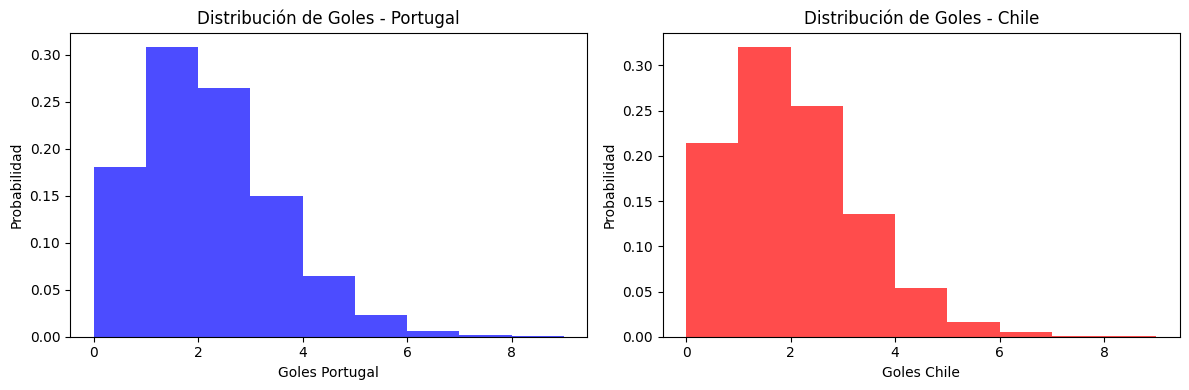

In [20]:
# Distribucion de scorelines
from collections import Counter

score_counts = Counter(results)
top_scores = score_counts.most_common(15)

print("Scorelines más frecuentes:")
for score, count in top_scores:
    print(f"  {score[0]} - {score[1]}: {count} ({count/100:.1f}%)")

# Grafico de probabilidad de goles
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Goles del equipo local
home_goals = [h for h, a in results]
away_goals = [a for h, a in results]

axes[0].hist(home_goals, bins=range(0, 10), density=True, alpha=0.7, color='blue')
axes[0].set_xlabel(f'Goles {home_team}')
axes[0].set_ylabel('Probabilidad')
axes[0].set_title(f'Distribución de Goles - {home_team}')

axes[1].hist(away_goals, bins=range(0, 10), density=True, alpha=0.7, color='red')
axes[1].set_xlabel(f'Goles {away_team}')
axes[1].set_ylabel('Probabilidad')
axes[1].set_title(f'Distribución de Goles - {away_team}')

plt.tight_layout()
plt.show()

## Comparar equipos específicos

In [21]:
# Comparar varios partidos
matchups = [
    ("Spain", "France"),
    ("Argentina", "Brazil"),
    ("Germany", "Netherlands"),
    ("Japan", "South Korea"),
    ("Mexico", "United States")
]

print("Comparación de partidos:")
print("-" * 60)

for home, away in matchups:
    lambda_home, lambda_away = calculate_lambda(home, away, ratings_df)
    results = simulate_multiple_matches(home, away, ratings_df, n_simulations=1000)
    
    home_wins = sum(1 for h, a in results if h > a)
    away_wins = sum(1 for h, a in results if h < a)
    draws = sum(1 for h, a in results if h == a)
    
    avg_home = sum(h for h, a in results) / len(results)
    avg_away = sum(a for h, a in results) / len(results)
    
    print(f"{home} vs {away}")
    print(f"  Goles esperados: {lambda_home:.2f} - {lambda_away:.2f}")
    print(f"  Promedio real:   {avg_home:.2f} - {avg_away:.2f}")
    print(f"  Probabilidades: {home_wins/10:.1f}% V | {draws/10:.1f}% E | {away_wins/10:.1f}% D")
    print()

Comparación de partidos:
------------------------------------------------------------
Spain vs France
  Goles esperados: 1.72 - 1.58
  Promedio real:   1.76 - 1.58
  Probabilidades: 42.6% V | 23.5% E | 33.9% D

Argentina vs Brazil
  Goles esperados: 1.73 - 1.50
  Promedio real:   1.76 - 1.54
  Probabilidades: 43.4% V | 21.4% E | 35.2% D

Germany vs Netherlands
  Goles esperados: 1.62 - 1.59
  Promedio real:   1.65 - 1.61
  Probabilidades: 39.4% V | 22.7% E | 37.9% D

Japan vs South Korea
  Goles esperados: 1.68 - 1.52
  Promedio real:   1.67 - 1.62
  Probabilidades: 40.3% V | 22.1% E | 37.6% D

Mexico vs United States
  Goles esperados: 1.60 - 1.49
  Promedio real:   1.56 - 1.46
  Probabilidades: 39.0% V | 26.0% E | 35.0% D



## Función interactiva para simular cualquier partido

In [22]:
def simular_partido(team1, team2, n=10):
    """Simular un partido y mostrar resultados"""
    print(f"\n{'='*50}")
    print(f"SIMULACIÓN: {team1} vs {team2}")
    print(f"{'='*50}")
    
    # Ratings
    r1 = get_team_rating(team1, ratings_df)
    r2 = get_team_rating(team2, ratings_df)
    print(f"Ratings: {team1}={r1:.0f}, {team2}={r2:.0f}")
    
    # Goles esperados
    lambda1, lambda2 = calculate_lambda(team1, team2, ratings_df)
    print(f"Goles esperados: {lambda1:.2f} - {lambda2:.2f}")
    
    # Simular n partidos
    results = simulate_multiple_matches(team1, team2, ratings_df, n)
    
    v1 = sum(1 for h, a in results if h > a)
    v2 = sum(1 for h, a in results if h < a)
    e = sum(1 for h, a in results if h == a)
    
    print(f"\nResultados ({n} simulaciones):")
    print(f"  {team1}: {v1} victorias ({v1/n*100:.1f}%)")
    print(f"  Empates: {e} ({e/n*100:.1f}%)")
    print(f"  {team2}: {v2} victorias ({v2/n*100:.1f}%)")
    
    # Scorelines comunes
    scores = Counter(results).most_common(5)
    print(f"\nScorelines más comunes:")
    for (g1, g2), cnt in scores:
        print(f"  {g1}-{g2}: {cnt} veces ({cnt/n*100:.1f}%)")

# Ejemplo de uso
simular_partido("Argentina", "Brazil")


SIMULACIÓN: Argentina vs Brazil
Ratings: Argentina=1753, Brazil=1663
Goles esperados: 1.73 - 1.50

Resultados (10 simulaciones):
  Argentina: 6 victorias (60.0%)
  Empates: 1 (10.0%)
  Brazil: 3 victorias (30.0%)

Scorelines más comunes:
  2-1: 2 veces (20.0%)
  3-1: 1 veces (10.0%)
  2-0: 1 veces (10.0%)
  0-2: 1 veces (10.0%)
  5-1: 1 veces (10.0%)


In [23]:
# Puedes cambiar los equipos aquí
simular_partido("Chile", "Spain")


SIMULACIÓN: Chile vs Spain
Ratings: Chile=1435, Spain=1808
Goles esperados: 1.30 - 1.84

Resultados (10 simulaciones):
  Chile: 4 victorias (40.0%)
  Empates: 1 (10.0%)
  Spain: 5 victorias (50.0%)

Scorelines más comunes:
  1-0: 2 veces (20.0%)
  0-4: 2 veces (20.0%)
  1-2: 1 veces (10.0%)
  3-1: 1 veces (10.0%)
  2-2: 1 veces (10.0%)


In [39]:
# También puedes simular con equipos de menor rating
simular_partido("Argentina", "France", n=100)


SIMULACIÓN: Argentina vs France
Ratings: Argentina=1753, France=1776
Goles esperados: 1.24 - 1.43

Resultados (100 simulaciones):
  Argentina: 25 victorias (25.0%)
  Empates: 30 (30.0%)
  France: 45 victorias (45.0%)

Scorelines más comunes:
  1-1: 16 veces (16.0%)
  0-1: 16 veces (16.0%)
  1-2: 9 veces (9.0%)
  2-1: 8 veces (8.0%)
  2-2: 7 veces (7.0%)


In [40]:
# Comparar distintos tipos de partidos
test_matches = [

    # TOP vs TOP
    ("Spain", "France"),
    ("Argentina", "Brazil"),
    ("Germany", "Netherlands"),
    ("England", "Portugal"),
    ("Italy", "Croatia"),

    # Equipos parejos medios
    ("Japan", "South Korea"),
    ("Mexico", "United States"),
    ("Morocco", "Turkey"),
    ("Switzerland", "Denmark"),

    # Favorito moderado
    ("Argentina", "Japan"),
    ("France", "Mexico"),
    ("Brazil", "United States"),
    ("Germany", "Morocco"),

    # Favorito fuerte
    ("Spain", "New Zealand"),
    ("Argentina", "Canada"),
    ("France", "South Africa"),
    ("England", "Saudi Arabia"),

    # Ultra desiguales
    ("Brazil", "San Marino"),
    ("France", "India"),
    ("Germany", "Malta"),

    # Equipos defensivos
    ("Italy", "Uruguay"),
    ("Croatia", "Switzerland"),

    # Equipos ofensivos
    ("Brazil", "Portugal"),
    ("France", "Argentina"),

    # Posibles sorpresas
    ("Japan", "Germany"),
    ("Morocco", "Spain"),
]

print("=" * 70)
print("COMPARACIÓN DE PARTIDOS")
print("=" * 70)

for home, away in test_matches:

    lambda_home, lambda_away = calculate_lambda(
        home,
        away,
        ratings_df
    )

    results = simulate_multiple_matches(
        home,
        away,
        ratings_df,
        n_simulations=500
    )

    home_wins = sum(1 for h, a in results if h > a)
    away_wins = sum(1 for h, a in results if h < a)
    draws = sum(1 for h, a in results if h == a)

    avg_home = sum(h for h, a in results) / len(results)
    avg_away = sum(a for h, a in results) / len(results)

    total_goals = avg_home + avg_away

    print(f"{home} vs {away}")
    print("-" * 50)

    print(f"Ratings:")
    print(f"  {home}: {get_team_rating(home, ratings_df):.0f}")
    print(f"  {away}: {get_team_rating(away, ratings_df):.0f}")

    print(f"\nGoles esperados (lambda):")
    print(f"  {lambda_home:.2f} - {lambda_away:.2f}")

    print(f"\nPromedio simulado:")
    print(f"  {avg_home:.2f} - {avg_away:.2f}")

    print(f"\nProbabilidades:")
    print(f"  {home}: {home_wins/10:.1f}%")
    print(f"  Empate: {draws/10:.1f}%")
    print(f"  {away}: {away_wins/10:.1f}%")

    print(f"\nPromedio total goles:")
    print(f"  {total_goals:.2f}")

    # Diagnóstico rápido
    if total_goals > 3.5:
        print("  ⚠️ Muchos goles")
    elif total_goals < 1.8:
        print("  ⚠️ Muy pocos goles")

    if max(home_wins, away_wins) > 90:
        print("  ⚠️ Favorito demasiado dominante")

    print("\n" + "=" * 70 + "\n")

COMPARACIÓN DE PARTIDOS
Spain vs France
--------------------------------------------------
Ratings:
  Spain: 1808
  France: 1776

Goles esperados (lambda):
  1.51 - 1.24

Promedio simulado:
  1.53 - 1.23

Probabilidades:
  Spain: 45.3%
  Empate: 25.3%
  France: 29.4%

Promedio total goles:
  2.76
  ⚠️ Favorito demasiado dominante


Argentina vs Brazil
--------------------------------------------------
Ratings:
  Argentina: 1753
  Brazil: 1663

Goles esperados (lambda):
  1.80 - 1.05

Promedio simulado:
  1.78 - 1.06

Probabilidades:
  Argentina: 54.5%
  Empate: 23.7%
  Brazil: 21.8%

Promedio total goles:
  2.85
  ⚠️ Favorito demasiado dominante


Germany vs Netherlands
--------------------------------------------------
Ratings:
  Germany: 1680
  Netherlands: 1708

Goles esperados (lambda):
  1.21 - 1.44

Promedio simulado:
  1.17 - 1.51

Probabilidades:
  Germany: 29.0%
  Empate: 26.6%
  Netherlands: 44.4%

Promedio total goles:
  2.67
  ⚠️ Favorito demasiado dominante


England vs Po

In [48]:
simular_partido("Peru","Chile",n=1000)


SIMULACIÓN: Peru vs Chile
Ratings: Peru=1445, Chile=1435
Goles esperados: 1.40 - 1.32

Resultados (1000 simulaciones):
  Peru: 369 victorias (36.9%)
  Empates: 281 (28.1%)
  Chile: 350 victorias (35.0%)

Scorelines más comunes:
  1-1: 138 veces (13.8%)
  0-1: 84 veces (8.4%)
  1-0: 84 veces (8.4%)
  2-1: 83 veces (8.3%)
  0-0: 77 veces (7.7%)
